# 📊 Sales & Revenue Intelligence — Analysis Notebook

An end-to-end analysis of the real **Sample - Superstore** dataset that goes beyond pretty charts. For each limitation of a typical sales dashboard, this notebook shows the **fix**:

| # | Limitation of the typical dashboard | The fix shown below |
|---|---|---|
| 3 | Breaks on messy data | Auditable cleaning pipeline |
| 2 | Vanity metric: total sales | Profit & margin → loss-making bestsellers |
| 1a | Only backward-looking | Back-tested forecast (model selection) |
| 1b | Silent on sudden changes | Automatic anomaly detection |
| 1c | Ends at a chart | Quantified recommendations |

## 0 · Setup

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path.cwd()))
import pandas as pd
from IPython.display import Image, display
from src import pipeline
from src.superstore_loader import ensure_dataset
pipeline.CURRENCY = '$'        # this is US data
pd.set_option('display.max_columns', 30)
print('Setup complete · Python', sys.version.split()[0])

Setup complete · Python 3.14.5


## 1 · Load the real Superstore data
Auto-downloads on first run. This public mirror is *deliberately messy* — perfect for showing the cleaning step on genuinely real data.

In [2]:
csv = ensure_dataset('data/superstore.csv')
raw = pd.read_csv(csv)
print('Raw shape:', raw.shape)
raw.head()

  using cached dataset -> data\superstore.csv
Raw shape: (10800, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3,CA-2017-138688,6/12/2017,6/16/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164


### Real data is messy
Before trusting any total, look at the data quality. A naive `read_csv().sum()` would silently include hundreds of blank rows.

In [3]:
print('Fully-blank order dates :', raw['Order Date'].isna().sum())
print('Exact duplicate rows     :', raw.duplicated().sum())
raw.isna().sum().to_frame('nulls').query('nulls > 0')

Fully-blank order dates : 806
Exact duplicate rows     : 504


,nulls
Order Date,806
Ship Date,806
Ship Mode,806
Customer ID,806
Customer Name,806
Segment,806
Country,806
City,806
State,806
Postal Code,817


## 2 · Clean the data — **FIX #3**
The cleaner parses dates, drops blank/duplicate rows, normalises text and validates numbers — and **logs every fix** so the work is auditable.

In [4]:
df, report = pipeline.clean_data(csv)
pd.Series(report, name='value').to_frame()

,value
rows_loaded,10800.0
invalid_or_blank_dates_dropped,806.0
duplicates_removed,0.0
sales_recomputed,0.0
sales_unfixable_dropped,0.0
nonpositive_qty_removed,0.0
price_outliers_removed,0.0
rows_clean,9994.0
pct_retained,92.5


> ✅ Loaded 10,800 rows → kept the canonical **9,994** real transactions (92.5%), having removed **806 blank junk rows**.

## 3 · Profitability — **FIX #2** (the headline)
Revenue is a vanity metric. **Profit and margin** tell the truth.

In [5]:
prof = pipeline.profitability_analysis(df)
print(f"Sales ${prof['total_sales']:,.0f}  |  "
      f"Profit ${prof['total_profit']:,.0f}  |  "
      f"Margin {prof['overall_margin_pct']:.1f}%")
prof['by_category']

Sales $2,297,201  |  Profit $286,397  |  Margin 12.5%


,sales,profit,margin_pct
category,,,
Technology,836154.0330,145454.9481,17.395712
Furniture,741999.7953,18451.2728,2.486695
Office Supplies,719047.0320,122490.8008,17.035158


### 🚨 Loss-making bestsellers
High-revenue sub-categories that **lose money** — the insight a 'top products' chart completely hides:

In [6]:
prof['loss_makers']

,sales,profit,orders,margin_pct
sub_category,,,,
Tables,206965.5320,-17725.4811,319,-8.564460
Bookcases,114879.9963,-3472.5560,228,-3.022768


> **Tables** and **Bookcases** sell well but lose **\$17,725** and **\$3,473** to deep discounting. This is the most famous real insight in this dataset.

## 4 · Forecast — **FIX #1a** (back-tested model selection)
Instead of reporting flattering *in-sample* error, we **hold out the last 6 months**, forecast them blind, and compare three models by true *out-of-sample* accuracy.

In [7]:
fc = pipeline.forecast_sales(df, periods=6)
print('Chosen model :', fc['model_name'])
print(f"OOS MAPE      : {fc['oos_mape']:.1f}%")
print(f"Next 6 months : ${fc['next_total']:,.0f}")
fc['comparison']

Chosen model : Holt-Winters
OOS MAPE      : 15.6%
Next 6 months : $361,842


,model,oos_mape,oos_rmse
0,Holt-Winters,15.6,17770.0
1,"SARIMAX(1,1,1)(1,1,1,12)",17.4,16839.0
2,Holt-Winters (log),21.3,19395.0


## 5 · Anomaly detection — **FIX #1b**
Flag any day outside a rolling mean ± 3σ band — automatic, objective monitoring instead of eyeballing a line chart.

In [8]:
anom = pipeline.detect_anomalies(df)
print('Anomaly days flagged:', len(anom['anomalies']))
anom['anomalies'].tail(5).to_frame('sales')

Anomaly days flagged: 23


,sales
order_date,
2017-10-21,7951.5920
2018-03-23,14816.0680
2018-07-03,6963.4040
2018-10-22,15158.8770
2018-11-17,13694.8828


## 6 · Recommendations — **FIX #1c**
Numbers are useless without an action. The pipeline turns the analysis into quantified business recommendations.

In [9]:
for i, r in enumerate(pipeline.generate_recommendations(prof, fc, anom), 1):
    print(f'{i}. {r}\n')

1. CAP DISCOUNTS on loss-making bestsellers (Tables, Bookcases). 'Tables' sells well but LOSES $17,725 (margin -8.6%). Capping discount near the break-even band turns these from a drain into profit.

2. DOUBLE DOWN on 'Technology' - it drives $145,455 profit at 17.4% margin. Prioritise its inventory and marketing spend.

3. PLAN FOR THE PEAK: the best back-tested model (Holt-Winters) projects $361,842 in sales over the next 6 months (out-of-sample MAPE 15.6%). Pre-stock and add staff before the seasonal surge.

4. INVESTIGATE 23 ANOMALY DAY(S) the system flagged automatically (e.g. 17 Nov 2018). Sudden swings are usually a stock-out, pricing bug, or a one-off bulk order worth understanding - not guessing.



## 7 · The executive dashboard
All four views in one image (also saved to `outputs/`).

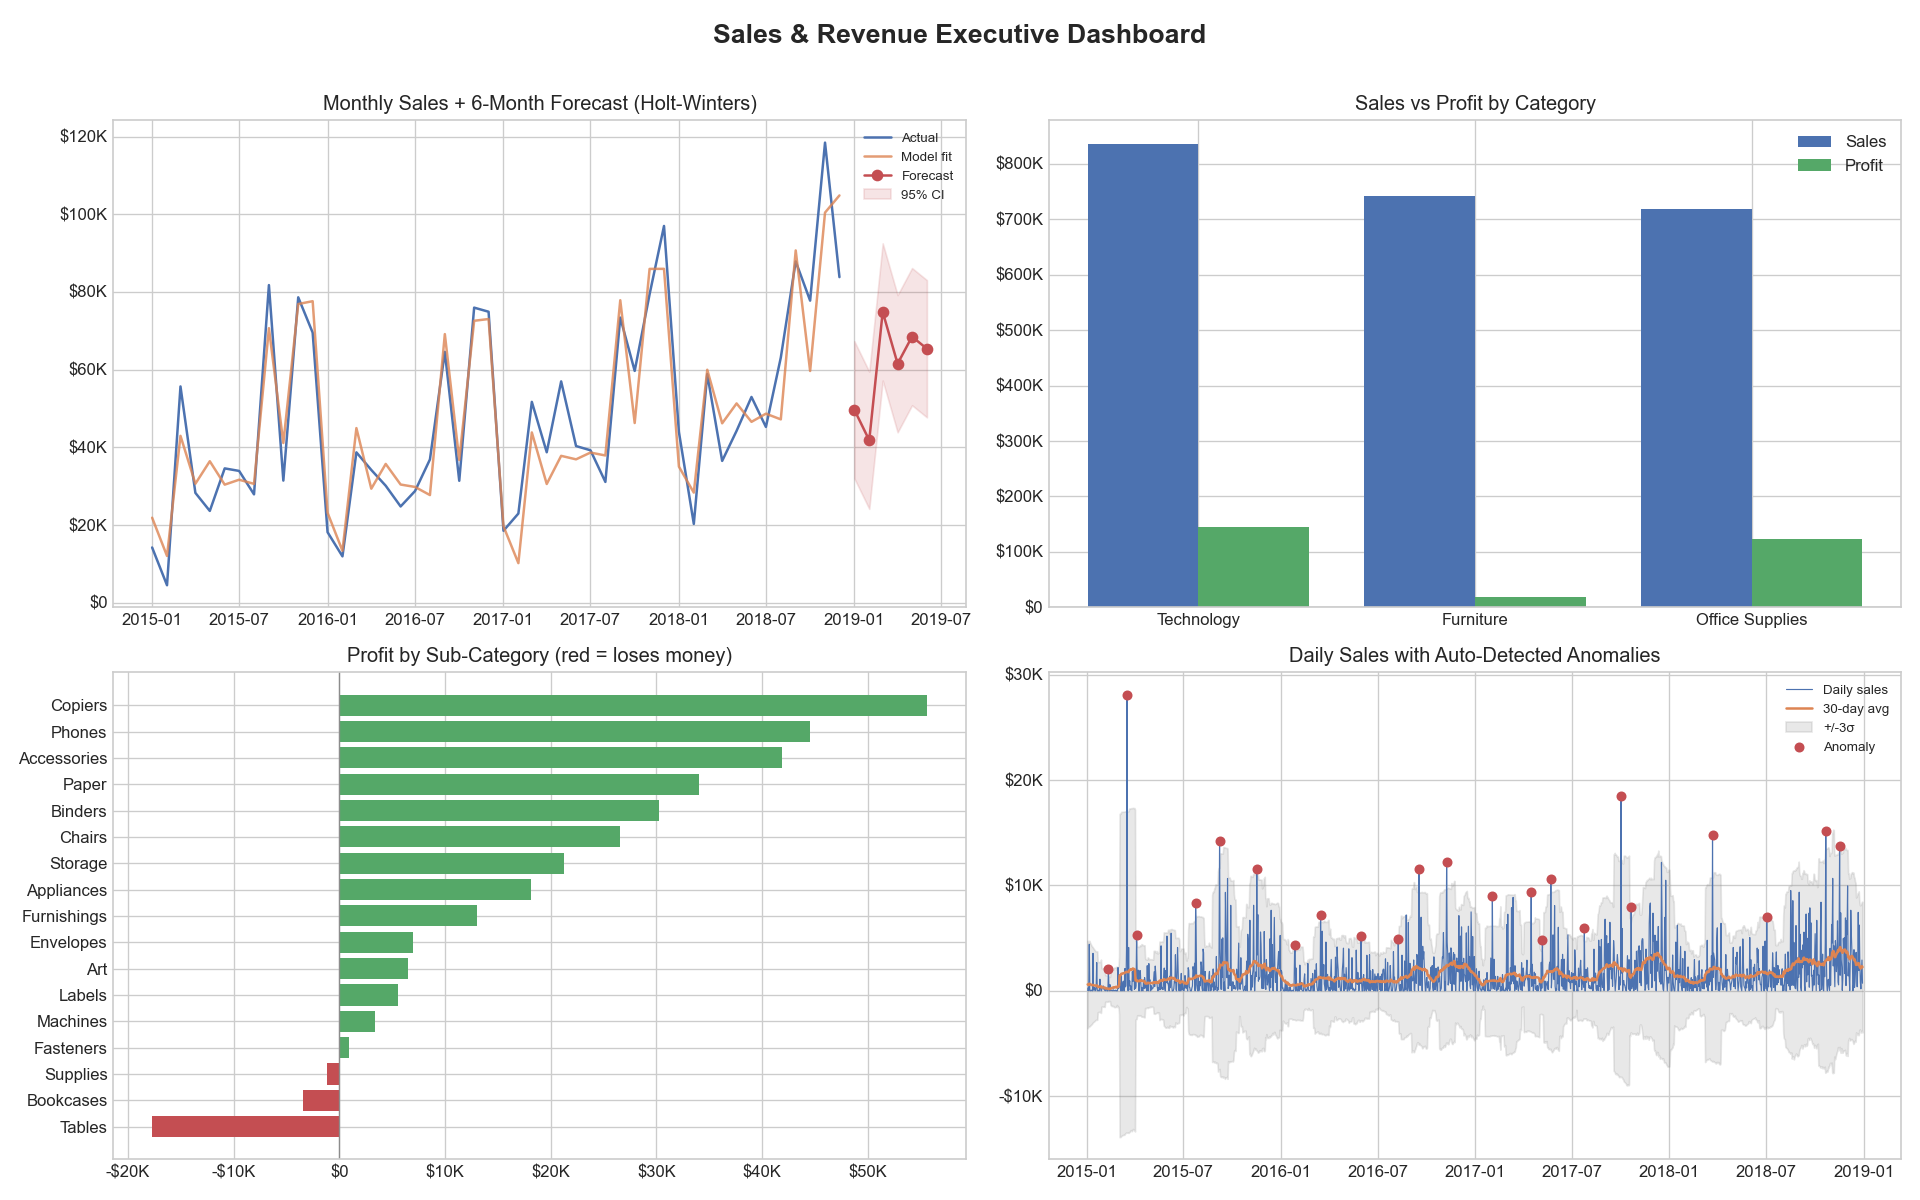

In [10]:
pipeline.save_all_charts(prof, fc, anom, 'outputs')
display(Image('outputs/dashboard.png'))

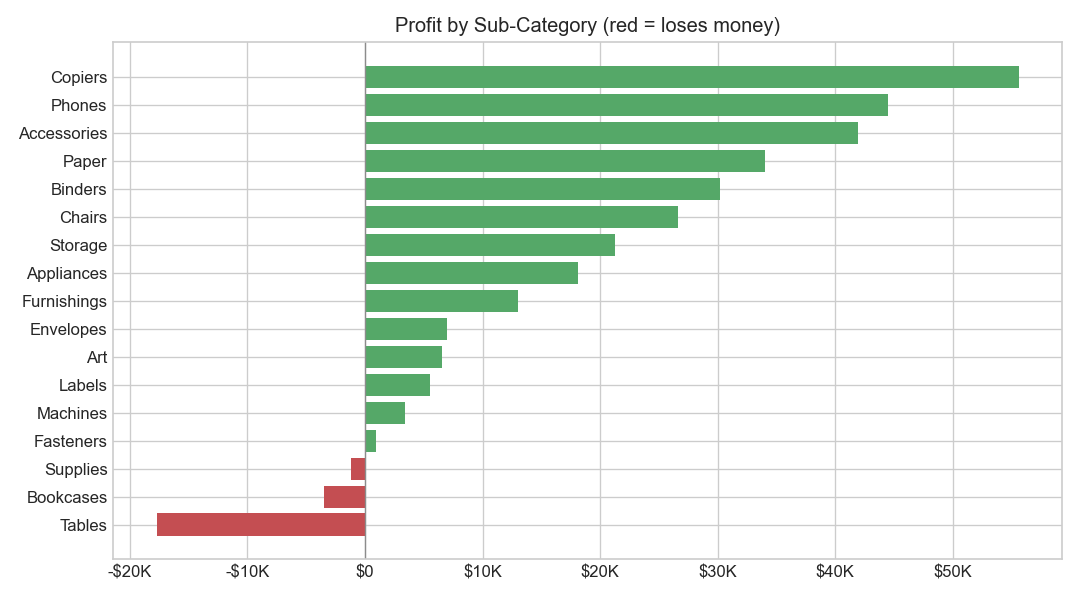

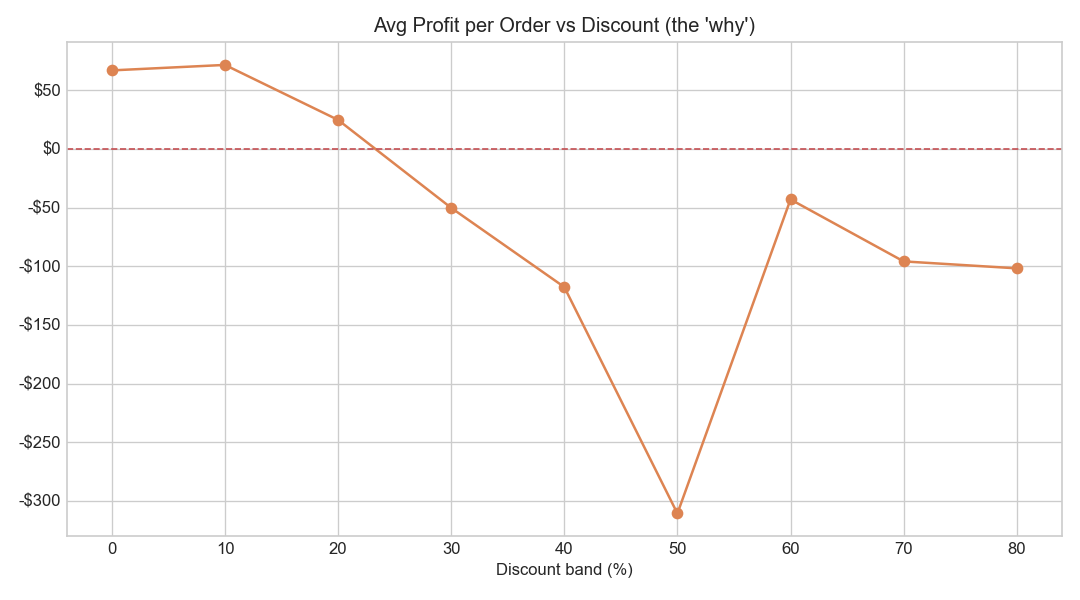

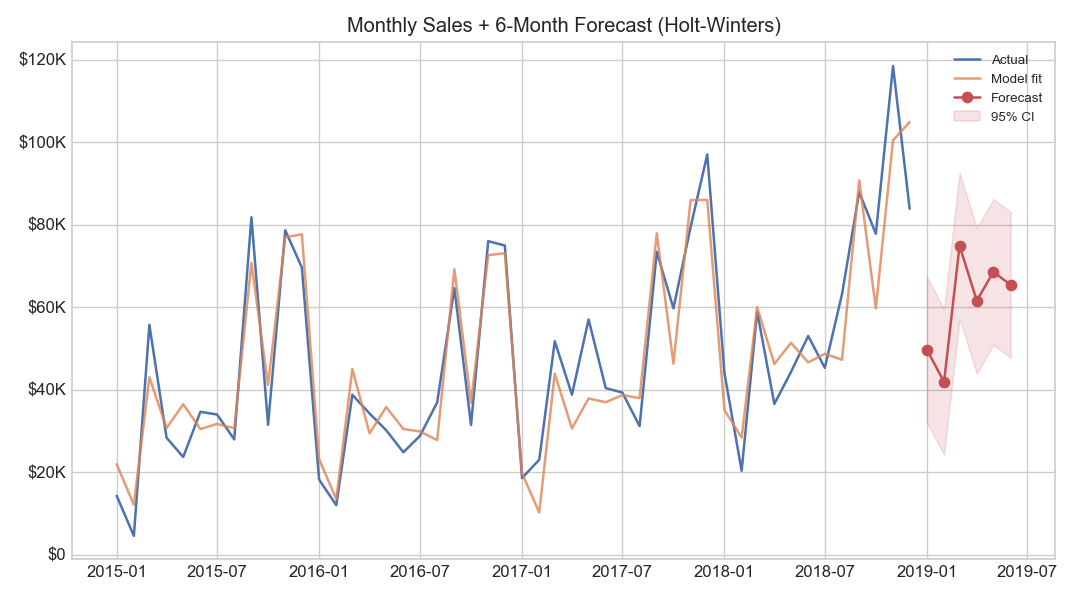

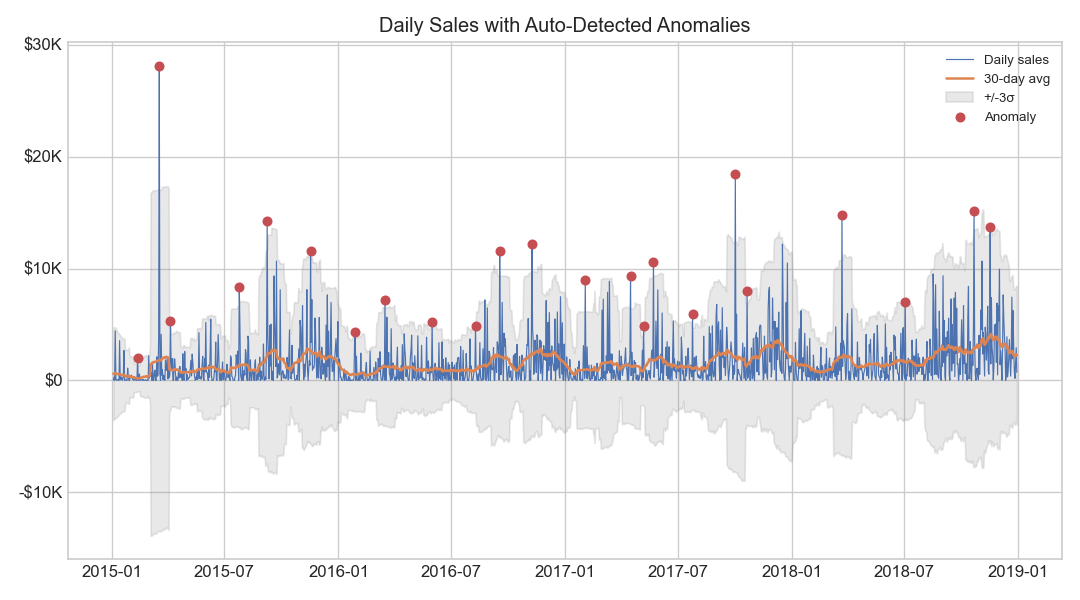

In [11]:
for img in ['loss_making_products.png', 'discount_vs_profit.png',
            'sales_forecast.png', 'anomaly_detection.png']:
    display(Image(f'outputs/{img}'))

## ✅ Conclusion
This isn't a chart-making exercise — it's an analyst workflow: **clean** messy real data, **question** the vanity metrics, **predict** the future with back-tested rigour, **monitor** for anomalies, and **recommend** concrete actions.

**Limitations & next steps:** the forecast is univariate (a SARIMAX with promotions/holidays as drivers would improve it); anomaly detection is statistical, not causal. See the [README](../README.md) for the full write-up.